In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, recall_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

dataset内容分析和重新采样

In [2]:
# 文件路径
root_path = "C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/"
training_path = root_path + "dataset_training/"

def print_label_distribution(df, column_name):
    if isinstance(df, pd.DataFrame):
        y = df[column_name]
    else:
        y = df
    label_counts = y.value_counts()
    print("Current label distribution:")
    print(label_counts)


# 分别对每种标签进行采样
def get_resampled_df(df, column, target_per_class, num_classes=[2, 1, 1], replace=True):
    # 按照标签分为三类
    df_0 = df[df[column] == 0]
    df_1 = df[df[column] == 1]
    df_2 = df[df[column] == 2]

    df_0_resampled = resample(
        df_0,
        replace=replace,
        n_samples=round(target_per_class * num_classes[0]),
        random_state=42,
    )
    df_1_resampled = resample(
        df_1,
        replace=replace,
        n_samples=round(target_per_class * num_classes[1]),
        random_state=42,
    )
    df_2_resampled = resample(
        df_2,
        replace=replace,
        n_samples=round(target_per_class * num_classes[2]),
        random_state=42,
    )

    # 合并重新采样后的数据集
    df_resampled_012 = pd.concat([df_0_resampled, df_1_resampled, df_2_resampled])
    # df_resampled_012.to_csv(f"{preprocessed_path}resampled_mapped_{freq}.csv", index=False)
    return df_resampled_012

In [3]:
def test_data_distribution(df,type="training", freq="D"):
    # df = pd.read_csv(f"{training_path}{type}_dataset_{stockmarket}_{freq}.csv")
    print(f"Label distribution before resampling {freq}:")
    print_label_distribution(df, "top_or_bottom")
    print_label_distribution(df, "top_or_bottom_stat")
    print_label_distribution(df, "top_bottom_volatility_stat")
    print_label_distribution(df, "top_or_bottom_optimized")
    print_label_distribution(df, "top_or_bottom_stat_optimized")
    print_label_distribution(df, "top_bottom_volatility_optimized")
    del df

In [4]:
high_importance_features = [
    "change",
    "pct_chg",
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",  # 新加重要特征
    "upper_shadow",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
]

high_importance_features_v2 = [
    "change",
    "pct_chg",
    "vol",
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",
    "dea",
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    # "pe",
    # "pe_ttm", 当为负值时得到的数据为NaN
    "pb",
    "ps",
    "ps_ttm",
    # "dv_ratio",
    # "dv_ttm",
    "total_share",
    "float_share",
    "free_share",
    "total_mv",
    "circ_mv",
    # "float_share_ratio",
    "free_share_ratio",
]

high_importance_features_v3 = [
    "change",
    "pct_chg",
    # "vol",0.02
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    # "dif",0.02
    # "dea",0.02
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    # "pe",
    # "pe_ttm", 当为负值时得到的数据为NaN
    "pb",
    # "ps",0.02
    # "ps_ttm",0.02
    # "dv_ratio",0.02
    # "dv_ttm",0.02
    # "total_share",0.02
    # "float_share",0.02
    "free_share",
    # "total_mv",0.02
    # "circ_mv",0.02
    # "float_share_ratio",0.02
    # "free_share_ratio",0.02
    "mab_10",
    "mab_25",
    "mab_60",
    "mab_120",
    "mab_200",
]

high_importance_features_v3_M = [
    "change",
    "pct_chg",
    # "vol",0.02
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    # "dif",0.02
    # "dea",0.02
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    # "pe",
    # "pe_ttm", 当为负值时得到的数据为NaN
    "pb",
    # "ps",0.02
    # "ps_ttm",0.02
    # "dv_ratio",0.02
    # "dv_ttm",0.02
    # "total_share",0.02
    # "float_share",0.02
    "free_share",
    # "total_mv",0.02
    # "circ_mv",0.02
    # "float_share_ratio",0.02
    # "free_share_ratio",0.02
    "mab_10",
    "mab_25",
]

high_importance_tech_features = [
    "change",
    "pct_chg",
    "vol",
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",
    "dea",
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
]

low_importance_features = [
    "change_nearest",
    "pct_chg_nearest",
    "pct_vol_chg_nearest",
    "vol_nearest",
    "k_nearest",
    "d_nearest",
    "j_nearest",
    "dif_nearest",
    "dea_nearest",
    "bar_nearest",
    "rsi_6_nearest",
    "rsi_12_nearest",
    "rsi_24_nearest",
    "atr_nearest",
    "turnover_rate_nearest",
    "turnover_rate_f_nearest",
    "volume_ratio_nearest",
    "pct_o2c_nearest",
    "upper_shadow_nearest",
    "pe_nearest",
    "pe_ttm_nearest",
    "pb_nearest",
    "ps_nearest",
    "ps_ttm_nearest",
    "dv_ratio_nearest",
    "dv_ttm_nearest",
    "float_share_ratio_nearest",
    "free_share_ratio_nearest",
]

full_features = [
    "change",
    "pct_chg",
    "vol",
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",
    "dea",
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    "pe",
    "pe_ttm",
    "pb",
    "ps",
    "ps_ttm",
    "dv_ratio",
    "dv_ttm",
    "total_share",
    "float_share",
    "free_share",
    "total_mv",
    "circ_mv",
    "float_share_ratio",
    "free_share_ratio",
    "change_nearest",
    "pct_chg_nearest",
    "pct_vol_chg_nearest",
    "vol_nearest",
    "k_nearest",
    "d_nearest",
    "j_nearest",
    "dif_nearest",
    "dea_nearest",
    "bar_nearest",
    "rsi_6_nearest",
    "rsi_12_nearest",
    "rsi_24_nearest",
    "atr_nearest",
    "turnover_rate_nearest",
    "turnover_rate_f_nearest",
    "volume_ratio_nearest",
    "pct_o2c_nearest",
    "upper_shadow_nearest",
    "pe_nearest",
    "pe_ttm_nearest",
    "pb_nearest",
    "ps_nearest",
    "ps_ttm_nearest",
    "dv_ratio_nearest",
    "dv_ttm_nearest",
    "float_share_ratio_nearest",
    "free_share_ratio_nearest",
]


def split_data_and_labels(
    df,
    y_label="top_or_bottom_optimized",
    label_columns=[
        "top_or_bottom",
        "top_or_bottom_stat",
        "top_bottom_volatility_stat",
        "top_or_bottom_optimized",
        "top_or_bottom_stat_optimized",
        "top_bottom_volatility_optimized",
    ],
    important_features_only=False,
    features=high_importance_features,
):
    labels = {}
    for label_column in label_columns:
        labels[label_column] = df.pop(label_column)
    X = df[features] if important_features_only else df[full_features]
    y = labels[y_label]
    return X, y


def load_datasets(
    stockmarket="SHMAIN",
    freq="D",
    target_per_class=10000,
    num_classes=[2, 1, 1],
    target_column="STDOPT",
    important_features_only=False,
    features=high_importance_features,
):
    labels = {
        "STD": "top_or_bottom",
        "STAT": "top_or_bottom_stat",
        "VOL": "top_bottom_volatility_stat",
        "STDOPT": "top_or_bottom_optimized",
        "STATOPT": "top_or_bottom_stat_optimized",
        "VOLOPT": "top_bottom_volatility_optimized",
    }
    
    # 读取分割后的数据集
    train_df = pd.read_csv(training_path + f"train_dataset_{stockmarket}_{freq}.csv")
    # step. resampling
    train_df = get_resampled_df(
        train_df,
        column=labels[target_column],
        target_per_class=target_per_class,
        num_classes=num_classes,
    )
    
    test_df = pd.read_csv(training_path + f"test_dataset_{stockmarket}_{freq}.csv")

    # 提取特征和标签
    X_train, y_train = split_data_and_labels(
        train_df,
        y_label=labels[target_column],
        features=features,
        important_features_only=important_features_only,
    )
    X_test, y_test = split_data_and_labels(
        test_df,
        y_label=labels[target_column],
        features=features,
        important_features_only=important_features_only,
    )

    return X_train, X_test, y_train, y_test

处理周线/月线训练集重新采样

In [3]:
freq = "D"
version = "0.1"
df_d = pd.read_csv(f"{training_path}mapped_entry_{freq}_cleaned_{version}.csv") 

In [7]:
df_d.describe()

,open,high,low,pre_close,change,pct_chg,vol,amount,atr,sl_atr,...,top_or_bottom_stat_optimized,top_or_bottom_optimized,top_bottom_volatility_optimized,close_df1,volume_ratio,ps,ps_ttm,dv_ratio,dv_ttm,circ_mv
count,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422471e+07,1.422473e+07,1.422473e+07,...,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07,1.422473e+07
mean,1.277619e+01,1.306129e+01,1.251842e+01,1.604386e+01,-3.256495e+00,-1.691929e+01,1.291182e+05,1.530382e+05,5.632736e-01,1.222409e+01,...,1.074845e-01,5.059468e-01,6.822366e-02,1.278736e+01,1.087325e+00,3.114490e+01,2.262502e+01,9.768395e-01,1.159438e+00,1.100485e+06
std,2.500821e+01,2.549507e+01,2.456344e+01,2.907110e+01,1.075552e+01,2.436862e+01,3.492329e+05,4.118506e+05,1.081017e+00,2.406591e+01,...,4.090625e-01,7.662882e-01,3.290763e-01,2.502164e+01,1.461399e+00,4.948580e+03,3.836816e+03,1.778864e+00,8.473179e+00,5.170014e+06
min,9.000000e-02,1.100000e-01,9.000000e-02,9.000000e-02,-3.272681e+03,-9.992920e+01,1.000000e+00,1.000000e-03,0.000000e+00,-9.700000e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e-02,0.000000e+00,1.520000e-02,1.510000e-02,0.000000e+00,0.000000e+00,2.030000e+03
25%,4.921100e+00,5.017800e+00,4.834300e+00,6.390000e+00,-3.248500e+00,-3.120440e+01,1.661530e+04,1.831850e+04,1.700000e-01,4.730000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,4.927600e+00,6.900000e-01,1.562600e+00,1.506000e+00,0.000000e+00,0.000000e+00,1.448494e+05
50%,8.060000e+00,8.223100e+00,7.911100e+00,1.042000e+01,-4.096000e-01,-3.840000e+00,4.643700e+04,5.073962e+04,3.100000e-01,7.740000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,8.070000e+00,9.100000e-01,3.207300e+00,3.071500e+00,3.745000e-01,4.032000e-01,3.242733e+05
75%,1.382520e+01,1.412460e+01,1.355480e+01,1.748000e+01,-2.000000e-02,-3.172000e-01,1.218749e+05,1.374208e+05,5.900000e-01,1.324000e+01,...,0.000000e+00,1.000000e+00,0.000000e+00,1.384000e+01,1.230000e+00,6.599900e+00,6.279900e+00,1.222500e+00,1.303400e+00,7.339556e+05
max,2.563742e+03,2.603268e+03,2.461726e+03,3.275000e+03,1.300000e+02,9.860656e+02,5.616135e+07,9.003765e+07,1.021400e+02,2.502960e+03,...,2.000000e+00,2.000000e+00,2.000000e+00,2.576640e+03,1.643660e+03,2.223993e+06,2.167926e+06,6.780270e+01,1.815770e+03,3.267370e+08


In [8]:
varsion = 0.1
df_d.to_csv(f"{training_path}mapped_entry_{freq}_cleaned_{version}.csv") 

In [9]:
nan_counts = df_d.isna().sum() > 0

# 打印每列的 NaN 值数量
print("NaN counts per column:")
print(nan_counts)

NaN counts per column:
ts_code_df1    False
trade_date     False
open           False
high           False
low            False
               ...  
ps             False
ps_ttm         False
dv_ratio       False
dv_ttm         False
circ_mv        False
Length: 64, dtype: bool


In [10]:
df_d.columns

Index(['ts_code_df1', 'trade_date', 'open', 'high', 'low', 'pre_close',
       'change', 'pct_chg', 'vol', 'amount', 'atr', 'sl_atr', 'sl_2atr',
       'sl_3atr', 'sl_4atr', 'sl_5atr', 'pct_vol_chg', 'pct_amount_chg',
       'close_atr_diff', 'close_2atr_diff', 'close_3atr_diff',
       'close_4atr_diff', 'close_5atr_diff', 'pct_o2c', 'lower_shadow',
       'upper_shadow', 'dif', 'dea', 'bar', 'rsi_6', 'rsi_12', 'rsi_24', 'k',
       'd', 'j', 'mab_10', 'mab_25', 'mab_60', 'mab_120', 'mab_200',
       'total_mv', 'total_share', 'float_share', 'free_share', 'turnover_rate',
       'turnover_rate_f', 'pe', 'pe_ttm', 'pb', 'float_share_ratio',
       'free_share_ratio', 'top_or_bottom', 'top_or_bottom_stat',
       'top_bottom_volatility_stat', 'top_or_bottom_stat_optimized',
       'top_or_bottom_optimized', 'top_bottom_volatility_optimized',
       'close_df1', 'volume_ratio', 'ps', 'ps_ttm', 'dv_ratio', 'dv_ttm',
       'circ_mv'],
      dtype='object')

In [ ]:
freq = "W"
df_w = pd.read_csv(f"{training_path}preprocessed_mapped_FULL_{freq}.csv")

In [17]:
freq = "M"
df_m = pd.read_csv(f"{training_path}preprocessed_mapped_FULL_{freq}.csv")

训练过程

In [5]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
from sklearn.svm import SVC


# 定义分割函数
def split_train_test(group, train_ratio=0.8):
    # 按 trade_date 排序
    group = group.sort_values("trade_date")
    # 计算分割点
    split_index = int(len(group) * train_ratio)
    # 分割成训练集和测试集
    train = group.iloc[:split_index]
    test = group.iloc[split_index:]
    return train, test


def get_train_test_data(df, group_by="ts_code", train_ratio=0.8):
    # 按 code 分组
    groups = df.groupby(group_by)
    # 对每个分组应用分割函数
    res = [split_train_test(group, train_ratio) for name, group in groups]
    # 拆分训练集和测试集
    train = pd.concat([t[0] for t in res])
    test = pd.concat([t[1] for t in res])

    train.to_csv(f"{training_path}train_dataset_{freq}_{version}.csv", index=False)
    test.to_csv(f"{training_path}test_dataset_{freq}_{version}.csv", index=False)
    print(f"train_dataset_{freq}_{version}.csv and test_dataset_{freq}_{version}.csv saved")
    return train, test


def train_model(
    X_train,
    y_train,
    model_name="logistic_regression",
    n_estimators=200,          # 增加树的数量，提升稳定性
    max_depth=10,              # 限制树深度，防止过拟合
    min_samples_leaf=10,       # 增加叶子节点最小样本数
    max_features='sqrt',       # 减少每次分割的特征子集大小
    class_weight='balanced',    # 处理类别不平衡（若存在）
    with_learning_curve=False,
    test_size=0.2,
    random_state=42,
):
    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=test_size, random_state=random_state
    # )
    model = None
    if model_name == "LR":
        model = LogisticRegression(max_iter=1000)
    elif model_name == "RF":
        model = RandomForestClassifier(
            n_estimators=n_estimators,          # 增加树的数量，提升稳定性
            max_depth=max_depth,              # 限制树深度，防止过拟合
            min_samples_leaf=min_samples_leaf,       # 增加叶子节点最小样本数
            max_features=max_features,       # 减少每次分割的特征子集大小
            class_weight=class_weight    # 处理类别不平衡（若存在）
        )
    elif model_name == "XGB":
        model = xgb.XGBClassifier()
    elif model_name == "LGBM":
        model = lgb.LGBMClassifier()
    elif model_name == "KNN":
        model = KNeighborsClassifier()
    elif model_name == "CAT":
        model = CatBoostClassifier()
    elif model_name == "SVM":
        model = SVC()
    elif model_name == "GBDT":
        model = GradientBoostingClassifier()
    elif model_name == "DNN":
        # DNN 模型的定义和训练代码
        pass
    elif model_name == "MLP":
        # MLP 模型的定义和训练代码
        pass
    elif model_name == "ANN":
        # ANN 模型的定义和训练代码
        pass
    else :
        raise ValueError("Invalid model name")
    model.fit(X_train, y_train)

    # y_pred = model.predict(X_test)
    # recall = recall_score(y_test, y_pred, average="weighted")
    # print(f"Recall: {recall}")
    # print(classification_report(y_test, y_pred))
    return model

def draw_learning_curve(model, X_train, y_train):
    # 生成学习曲线数据
    train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5)
    # 计算训练和测试得分的均值和标准差
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # 绘制学习曲线
    plt.figure()
    plt.title("Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    plt.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    plt.plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    plt.plot(
        train_sizes,
        test_scores_mean,
        "o-",
        color="g",
        label="Cross - validation score",
    )

    plt.legend(loc="best")
    plt.show()

In [ ]:
train, test_m = get_train_test_data(df_d, group_by="ts_code_df1", train_ratio=0.7)
# 保存数据集
freq = "D"
version = 0.1
train.to_csv(f"{training_path}train_dataset_{freq}_{version}.csv", index=False)
test_m.to_csv(f"{training_path}test_dataset_{freq}_{version}.csv", index=False)

In [6]:
def print_fit_report(model, X_test, y_test):
    y_pred = model.predict(X_test)
    recall = recall_score(y_test, y_pred, average="weighted")
    print(f"Recall: {recall}")
    print(classification_report(y_test, y_pred))

In [7]:
def feature_importance(model, X, model_name="random_forest"):
    # 显示特征重要性
    if model_name == "random_forest":
        feature_importances = model.feature_importances_
        features = X.columns
        importance_df = pd.DataFrame(
            {"Feature": features, "Importance": feature_importances}
        )
        importance_df = importance_df.sort_values(by="Importance", ascending=False)

        plt.figure(figsize=(10, 6))
        plt.title("Feature Importances")
        plt.barh(
            importance_df["Feature"],
            importance_df["Importance"],
            color="b",
            align="center",
        )
        plt.xlabel("Importance")
        plt.gca().invert_yaxis()
        plt.show()
        
        return importance_df

In [8]:
import pickle

def save_model(model, model_name="logistic_regression", freq="W", pred_type="STD"):
    # 保存模型到文件
    with open(f"{root_path}models/{model_name}_{pred_type}_{freq}.model", 'wb') as f:
        pickle.dump(model, f)

In [9]:
def split_data_labels(
    resample_df,
    y_label,
    features,
    keep_importance_features_only=True,
    split_before_resample=False,
    target_per_class=10000,
    num_classes=[3, 1.45, 1.37],
    replace=True,
):
    labels = {
        "STD": "top_or_bottom",
        "STAT": "top_or_bottom_stat",
        "VOL": "top_bottom_volatility_stat",
        "STDOPT": "top_or_bottom_optimized",
        "STATOPT": "top_or_bottom_stat_optimized",
        "VOLOPT": "top_bottom_volatility_optimized",
    }

    # step. resampling
    if split_before_resample:
        resample_df_train, resample_df_test = train_test_split(
            resample_df, test_size=0.2, random_state=42
        )

        resampled_df = get_resampled_df(
            resample_df_train,
            column=labels[y_label],
            target_per_class=target_per_class,
            num_classes=num_classes,  replace=replace
        )

        resample_df_test.dropna(inplace=True)
        
        X_test, y_test = split_data_and_labels(
            resample_df_test,
            y_label=labels[y_label],
            important_features_only=keep_importance_features_only,
            features=features,
        )
    else:
        resampled_df = get_resampled_df(
            resample_df,
            column=labels[y_label],
            target_per_class=target_per_class,
            num_classes=num_classes, replace=replace
        )

    X, y = split_data_and_labels(
        resampled_df,
        y_label=labels[y_label],
        important_features_only=keep_importance_features_only,
        features=features,
    )

    if split_before_resample:
        return resampled_df, X, X_test, y, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        return resampled_df, X_train, X_test, y_train, y_test


def training_bundle(
    resample_df,
    freq="D",
    model_name="random_forest",
    y_label="STD",
    target_per_class=10000,
    num_classes=[3, 1.45, 1.37],
    features=high_importance_features,
    save_resampled=False,
    save_model=False,
    with_learning_curve=False,
    keep_importance_features_only=False,
    split_before_resample=True,
    replace=True
):

    # step. split data and labels
    resampled_df, X_train, X_test, y_train, y_test = split_data_labels(
        split_before_resample=split_before_resample,
        resample_df=resample_df,
        y_label=y_label,
        target_per_class=target_per_class,
        num_classes=num_classes,
        keep_importance_features_only=keep_importance_features_only,
        features=features,replace=replace
    )
    # else:
    #     X_train, X_test, y_train, y_test = load_datasets(
    #         stockmarket=stockmarket,
    #         freq=freq,
    #         target_per_class=target_per_class,
    #         num_classes=num_classes,
    #         target_column=y_label,
    #         important_features_only=keep_importance_features_only,
    #         features=features,
    #     )

    if save_resampled:
        # step. saving resample data
        resampled_df.to_csv(
            f"{training_path}resampled_mapped_{freq}{str(num_classes)}.csv",
            index=False,
        )
    # step. training the data

    model = train_model(
        X_train, y_train, model_name=model_name, with_learning_curve=with_learning_curve
    )

    print_fit_report(model, X_test=X_test, y_test=y_test)

    if save_model:
        # step. saving trained model
        save_model(model, model_name=model_name, freq=freq, pred_type=y_label)
    return resampled_df, model, X_train, y_train

D
Current label distribution:
top_or_bottom_optimized
0    2693670
1    1346835
2    1346835
Name: count, dtype: int64
W
Current label distribution:
top_or_bottom_optimized
0    1013912
2     276994
1     270380
Name: count, dtype: int64
M
Current label distribution:
top_or_bottom_optimized
0    142015
2     43453
1     35509
Name: count, dtype: int64

D
Current label distribution:
top_or_bottom_stat_optimized
0    5313987
2      36899
1      36454
Name: count, dtype: int64
W
Current label distribution:
top_or_bottom_stat_optimized
0    1526076
2      18099
1      17111
Name: count, dtype: int64
M
Current label distribution:
top_or_bottom_stat_optimized
0    213205
2      4934
1      2838
Name: count, dtype: int64

D
Current label distribution:
top_bottom_volatility_optimized
0    5364919
1      11450
2      10971
Name: count, dtype: int64
W
Current label distribution:
top_bottom_volatility_optimized
0    1545479
2       8123
1       7684
Name: count, dtype: int64
M
Current label distribution:
top_bottom_volatility_optimized
0    215278
2      3485
1      2214
Name: count, dtype: int64

In [ ]:
print_label_distribution(df_w, "top_or_bottom")
print_label_distribution(df_w, "top_or_bottom_stat")
print_label_distribution(df_w, "top_bottom_volatility_stat")
print_label_distribution(df_w, "top_or_bottom_optimized")
print_label_distribution(df_w, "top_or_bottom_stat_optimized")
print_label_distribution(df_w, "top_bottom_volatility_optimized")

Current label distribution:
top_or_bottom_optimized
0    2192885
2     538953
1     538578
Name: count, dtype: int64
Current label distribution:
top_or_bottom_stat_optimized
0    3189975
2      41215
1      39226
Name: count, dtype: int64
Current label distribution:
top_bottom_volatility_optimized
0    3231624
1      19472
2      19320
Name: count, dtype: int64


In [60]:
print_label_distribution(df_m, "top_or_bottom")
print_label_distribution(df_m, "top_or_bottom_stat")
print_label_distribution(df_m, "top_bottom_volatility_stat")
print_label_distribution(df_m, "top_or_bottom_optimized")
print_label_distribution(df_m, "top_or_bottom_stat_optimized")
print_label_distribution(df_m, "top_bottom_volatility_optimized")

Current label distribution:
top_or_bottom
0    431429
2    170067
1    166326
Name: count, dtype: int64
Current label distribution:
top_or_bottom_stat
0.0    674655
Name: count, dtype: int64
Current label distribution:
top_bottom_volatility_stat
0.0    720337
Name: count, dtype: int64
Current label distribution:
top_or_bottom_optimized
0    501452
1    133752
2    132618
Name: count, dtype: int64
Current label distribution:
top_or_bottom_stat_optimized
0    737083
2     15817
1     14922
Name: count, dtype: int64
Current label distribution:
top_bottom_volatility_optimized
0    746544
2     10952
1     10326
Name: count, dtype: int64


In [ ]:
test_data_distribution(stockmarket="full",type="test", freq="M")

In [21]:
print_label_distribution(train, "top_or_bottom")
print_label_distribution(train, "top_or_bottom_stat")
print_label_distribution(train, "top_bottom_volatility_stat")
print_label_distribution(train, "top_or_bottom_optimized")
print_label_distribution(train, "top_or_bottom_stat_optimized")
print_label_distribution(train, "top_bottom_volatility_optimized")


Current label distribution:
top_or_bottom
0    5699273
1    2136783
2    2118719
Name: count, dtype: int64
Current label distribution:
top_or_bottom_stat
0    9114606
1     425899
2     414270
Name: count, dtype: int64
Current label distribution:
top_bottom_volatility_stat
0    9414806
1     277187
2     262782
Name: count, dtype: int64
Current label distribution:
top_or_bottom_optimized
0    6563339
2    1696052
1    1695384
Name: count, dtype: int64
Current label distribution:
top_or_bottom_stat_optimized
0    9229630
1     367780
2     357365
Name: count, dtype: int64
Current label distribution:
top_bottom_volatility_optimized
0    9482811
1     242019
2     229945
Name: count, dtype: int64


In [24]:
train.columns

Index(['ts_code_df1', 'trade_date', 'open', 'high', 'low', 'pre_close',
       'change', 'pct_chg', 'vol', 'amount', 'atr', 'sl_atr', 'sl_2atr',
       'sl_3atr', 'sl_4atr', 'sl_5atr', 'pct_vol_chg', 'pct_amount_chg',
       'close_atr_diff', 'close_2atr_diff', 'close_3atr_diff',
       'close_4atr_diff', 'close_5atr_diff', 'pct_o2c', 'lower_shadow',
       'upper_shadow', 'dif', 'dea', 'bar', 'rsi_6', 'rsi_12', 'rsi_24', 'k',
       'd', 'j', 'mab_10', 'mab_25', 'mab_60', 'mab_120', 'mab_200',
       'total_mv', 'total_share', 'float_share', 'free_share', 'turnover_rate',
       'turnover_rate_f', 'pe', 'pe_ttm', 'pb', 'float_share_ratio',
       'free_share_ratio', 'close_df1', 'volume_ratio', 'ps', 'ps_ttm',
       'dv_ratio', 'dv_ttm', 'circ_mv'],
      dtype='object')

In [ ]:
test_m.columns

Index(['ts_code_df1', 'trade_date', 'open', 'high', 'low', 'pre_close',
       'change', 'pct_chg', 'vol', 'amount', 'atr', 'sl_atr', 'sl_2atr',
       'sl_3atr', 'sl_4atr', 'sl_5atr', 'pct_vol_chg', 'pct_amount_chg',
       'close_atr_diff', 'close_2atr_diff', 'close_3atr_diff',
       'close_4atr_diff', 'close_5atr_diff', 'pct_o2c', 'lower_shadow',
       'upper_shadow', 'dif', 'dea', 'bar', 'rsi_6', 'rsi_12', 'rsi_24', 'k',
       'd', 'j', 'mab_10', 'mab_25', 'mab_60', 'mab_120', 'mab_200',
       'total_mv', 'total_share', 'float_share', 'free_share', 'turnover_rate',
       'turnover_rate_f', 'pe', 'pe_ttm', 'pb', 'float_share_ratio',
       'free_share_ratio', 'top_or_bottom', 'top_or_bottom_stat',
       'top_bottom_volatility_stat', 'top_or_bottom_stat_optimized',
       'top_or_bottom_optimized', 'top_bottom_volatility_optimized',
       'close_df1', 'volume_ratio', 'ps', 'ps_ttm', 'dv_ratio', 'dv_ttm',
       'circ_mv'],
      dtype='object')

In [ ]:
freq = "D"
version = 0.1
# 正常的话需要从文件中读取数据集
train_d = pd.read_csv(f"{training_path}train_dataset_{freq}_{version}.csv")

In [ ]:
freq = "W"
version = 0.1
# 正常的话需要从文件中读取数据集
train_w = pd.read_csv(f"{training_path}train_dataset_{freq}_{version}.csv")

In [11]:
freq = "M"
version = 0.1
# 正常的话需要从文件中读取数据集
train_m = pd.read_csv(f"{training_path}train_dataset_{freq}_{version}.csv")

In [12]:
train_m.describe()

,open,high,low,close_df1,pre_close,change,pct_chg,vol,amount,atr,...,total_mv,circ_mv,float_share_ratio,free_share_ratio,top_or_bottom,top_or_bottom_stat,top_bottom_volatility_stat,top_or_bottom_stat_optimized,top_or_bottom_optimized,top_bottom_volatility_optimized
count,413531.000000,413531.000000,413531.000000,413531.000000,413531.000000,413531.000000,413531.000000,4.135310e+05,4.135310e+05,413531.000000,...,4.135310e+05,4.135310e+05,413531.000000,413531.000000,413531.000000,413531.000000,413531.000000,413531.000000,413531.000000,413531.000000
mean,11.068816,12.415355,9.916067,11.008987,11.062416,-0.053430,0.909619,2.226992e+08,2.733386e+09,2.484455,...,1.374574e+06,9.908698e+05,0.713254,0.462734,0.662819,0.134070,0.093260,0.118804,0.526081,0.083711
std,14.600554,16.319113,12.906496,14.476804,14.579114,2.980294,15.660097,5.654508e+08,6.822897e+09,3.125043,...,6.555064e+06,4.703981e+06,0.266366,0.177868,0.819951,0.450792,0.379623,0.426200,0.774855,0.360603
min,0.220000,0.320000,0.210000,0.220000,0.220000,-174.750000,-82.550000,1.030000e+04,5.005100e+04,0.100000,...,1.042800e+04,2.502000e+03,0.015950,0.000406,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.910000,5.470000,4.480000,4.910000,4.910000,-0.560000,-7.270000,3.820686e+07,3.720113e+08,1.100000,...,2.400820e+05,1.456209e+05,0.495046,0.338600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.830000,8.740000,7.090000,7.820000,7.830000,-0.010000,-0.070000,9.606695e+07,1.057532e+09,1.750000,...,4.384736e+05,3.168547e+05,0.753008,0.458126,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,12.640000,14.150000,11.355000,12.590000,12.640000,0.560000,7.890000,2.254485e+08,2.700468e+09,2.820000,...,9.031932e+05,6.777395e+05,0.994921,0.588522,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,729.750000,775.330000,672.570000,727.410000,727.410000,180.990000,1032.670000,4.378306e+10,5.684316e+11,82.580000,...,2.665919e+08,2.168137e+08,1.003501,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [13]:
train_raw_m = train_m.copy()

In [17]:
train_m = train_raw_m

In [18]:
X_train_m, y_train_m = split_data_and_labels(
    train_m,
    y_label="top_or_bottom_optimized",
    important_features_only=True,
    features=high_importance_features_v3_M,
)

In [ ]:
X_train_m.describe()

,change,pct_chg,vol,atr,pct_vol_chg,pct_o2c,lower_shadow,upper_shadow,dif,dea,...,free_share,total_mv,circ_mv,float_share_ratio,free_share_ratio,mab_10,mab_25,mab_60,mab_120,mab_200
count,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,...,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06,9.954775e+06
mean,-4.427613e+00,-2.298676e+01,9.426228e+04,5.537358e-01,-1.427692e-01,7.153462e-04,1.018352e-02,1.035523e-02,-1.621176e-03,-1.642942e-03,...,3.728581e+04,1.289804e+06,8.144656e+05,6.277928e-01,4.271485e-01,1.063533e-03,3.081967e-03,7.491359e-03,1.481388e-02,2.514471e-02
std,1.246587e+01,2.640885e+01,2.845845e+05,9.933881e-01,2.930995e+00,2.885163e-02,1.111856e-02,1.145386e-02,8.465003e-01,7.963332e-01,...,1.209453e+05,6.564444e+06,4.176653e+06,2.810567e-01,1.769744e-01,5.586456e-02,9.328009e-02,1.473552e-01,2.111412e-01,2.786857e-01
min,-3.272681e+03,-9.992920e+01,1.000000e+00,0.000000e+00,-4.329783e+03,-1.076000e+00,-7.300000e-02,-2.100000e-02,-6.259000e+01,-5.590000e+01,...,3.293800e+00,5.545000e+03,2.030000e+03,1.421149e-02,4.060404e-04,-9.300000e-01,-9.300000e-01,-9.300000e-01,-9.500000e-01,-9.500000e-01
25%,-5.275600e+00,-4.400000e+01,1.174419e+04,1.700000e-01,-3.690000e-01,-1.400000e-02,3.000000e-03,3.000000e-03,-1.500000e-01,-1.400000e-01,...,6.750000e+03,2.252600e+05,1.052700e+05,3.815029e-01,2.998247e-01,-3.000000e-02,-5.000000e-02,-7.000000e-02,-1.000000e-01,-1.400000e-01
50%,-1.051600e+00,-9.700700e+00,3.286783e+04,3.100000e-01,-4.000000e-02,1.000000e-03,7.000000e-03,7.000000e-03,-1.000000e-02,-1.000000e-02,...,1.409345e+04,4.060367e+05,2.447889e+05,6.072870e-01,4.132948e-01,0.000000e+00,0.000000e+00,-1.000000e-02,-1.000000e-02,-2.000000e-02
75%,-1.141000e-01,-1.280900e+00,8.714383e+04,5.800000e-01,2.370000e-01,1.500000e-02,1.400000e-02,1.400000e-02,1.400000e-01,1.300000e-01,...,3.047907e+04,8.312113e+05,5.576931e+05,9.356893e-01,5.487054e-01,3.000000e-02,5.000000e-02,7.000000e-02,1.000000e-01,1.400000e-01
max,8.456720e+01,9.860656e+02,5.135467e+07,5.149000e+01,1.000000e+00,9.070000e-01,1.584000e+00,3.154000e+00,5.899000e+01,5.349000e+01,...,5.041233e+06,2.997884e+08,2.372158e+08,1.003501e+00,1.000000e+00,5.210000e+00,7.610000e+00,8.800000e+00,9.480000e+00,1.245000e+01


In [37]:
# 统计每个值的数量
print_label_distribution(y_train_m, None)

Current label distribution:
top_or_bottom_optimized
0    268571
2     72591
1     72369
Name: count, dtype: int64


需要把训练集和测试集normalization

In [ ]:
def normalize_data(df):
    # 归一化数据
    return (df - df.min()) / (df.max() - df.min())

模型code
- LR - logistic regression
- RF - random forest
- SVM - support vector machine
- ANN - artificial neural network
- DT - decision tree
- GBM - gradient boosting machine
- XGB - extreme gradient boosting
- LGB - light gradient boosting
- CAT - catboost


In [40]:
# 训练模型
model = train_model(
    X_train_m, y_train_m, model_name="RF", #with_learning_curve=True
)
print("Model training complete.")
# 保存模型
save_model(model, "RF", freq=freq, pred_type="STDOPT")
print("Model saved.")

Model training complete.
Model saved.


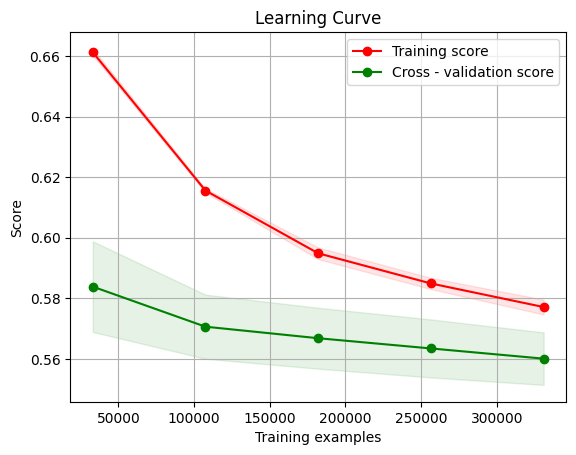

Feature importance calculated and plotted.


In [41]:
draw_learning_curve(model, X_train_m, y_train_m)
feature_importance(model, X_train_m, model_name="xgboost")
print("Feature importance calculated and plotted.")

In [42]:
test_m = pd.read_csv(f"{training_path}test_dataset_{freq}_{version}.csv")
print("Test dataset loaded.")
X_test_m, y_test_m = split_data_and_labels(
    test_m,
    y_label="top_or_bottom_optimized", 
    important_features_only=True,
    features=high_importance_features_v3_M,
)


Test dataset loaded.


In [43]:
print_label_distribution(y_test_m, None)

Current label distribution:
top_or_bottom_optimized
0    113729
1     34080
2     32533
Name: count, dtype: int64


In [44]:
print("Test dataset split into features and labels.")
print_fit_report(model, X_test_m, y_test_m)

Test dataset split into features and labels.
Recall: 0.5583058854842466
              precision    recall  f1-score   support

           0       0.81      0.46      0.58    113729
           1       0.42      0.73      0.53     34080
           2       0.42      0.73      0.54     32533

    accuracy                           0.56    180342
   macro avg       0.55      0.64      0.55    180342
weighted avg       0.66      0.56      0.57    180342



In [ ]:
X_test_m.describe()
y_test_m.describe()

count    4.269952e+06
mean     6.289392e-02
std      3.165744e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.000000e+00
Name: top_bottom_volatility_optimized, dtype: float64

In [ ]:
resampled_df, model, X, y = training_bundle(
    resample_df=df_d,
    freq="D",
    y_label="VOLOPT",
    model_name="xgboost",
    target_per_class=20000,
    num_classes=[10,3,3],
    with_learning_curve=True, 
    save_model=False, 
    save_resampled=False,
    keep_importance_features_only=True,
    features=high_importance_features_v2,
    split_before_resample=True,
    replace=True
)

In [ ]:
X_test_m = pd.read_csv(f"{training_path}SHMAIN_dataset_M.csv")
y_test_m = X_test_m.pop("top_or_bottom_stat_optimized")
X_test_m = X_test_m[high_importance_features_v2]

y_pred = model.predict(X_test_m)
recall = recall_score(y_test_m, y_pred, average="weighted")
print(f"Recall: {recall}")
print(classification_report(y_test_m, y_pred))

Recall: 0.9729299613464883
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    305563
           1       0.66      0.99      0.79      6093
           2       0.54      1.00      0.70      6297

    accuracy                           0.97    317953
   macro avg       0.73      0.99      0.83    317953
weighted avg       0.98      0.97      0.98    317953



训练要求
1. 非顶底的召回率越高越好 >98%
2. 顶和底的精度越高越好 >90%
3. 顶和底的召回率 >80%

In [39]:
del resampled_df
del X
del y
del model

In [27]:
save_model(model, model_name="random_forest(0.69)", freq="M", pred_type="STDOPT")

In [72]:
def release_mem(resampled_df, model, X, y):
    # del df_d
    # del df_w
    # del df_m
    del resampled_df
    del model
    del X
    del y
    


In [ ]:
release_mem(resampled_df=resampled_df,model=model, X=X, y=y)

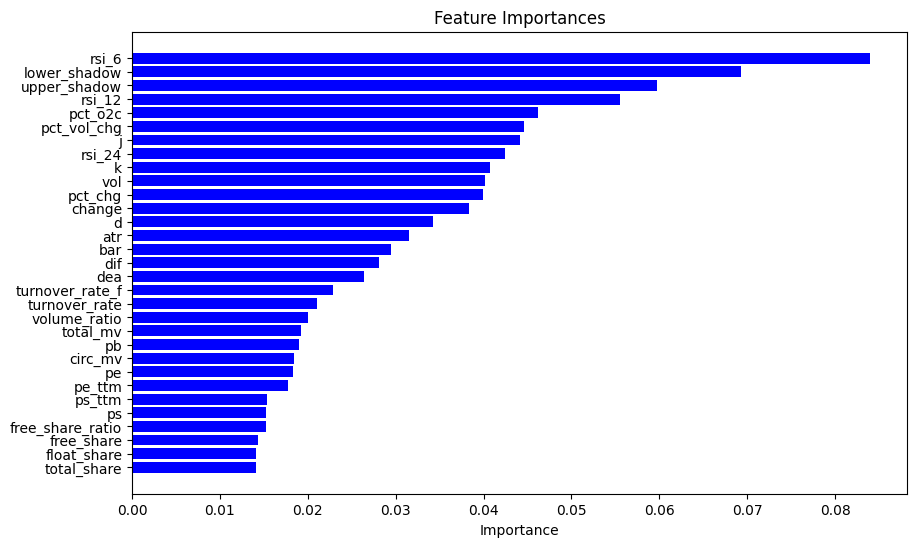

In [ ]:
importance_df = feature_importance(model, X, model_name="random_forest")

In [40]:
importance_df

,Feature,Importance
11,rsi_6,0.083980
6,lower_shadow,0.069346
7,upper_shadow,0.059694
12,rsi_12,0.055567
5,pct_o2c,0.046214
4,pct_vol_chg,0.044581
16,j,0.044155
13,rsi_24,0.042453
14,k,0.040709
2,vol,0.040197


def training_bundle_v2(
    freqs=["D","W","M"],
    model_name="random_forest",
    y_label="VOL",
    target_per_class=10000,
    num_classes=[3, 1.45, 1.37],
    save_resampled=False,
    save_model=False,
    with_learning_curve=False,
):
    labels = {
        "STAT": "top_or_bottom_stat_optimized",
        "STD": "top_or_bottom_optimized",
        "VOL": "top_bottom_volatility_optimized",
    }
    for freq in freqs:
        resample_df = pd.read_csv(f"{preprocessed_path}preprocessed_mapped_{freq}.csv")
        
        resampled_df = get_resampled_df(
            resample_df,
            column=labels[y_label],
            target_per_class=target_per_class,
            num_classes=num_classes,
        )
        X, y = split_data_and_labels(resampled_df, y_label=labels[y_label])

        if save_resampled:
            resampled_df.to_csv(
                f"{preprocessed_path}resampled_mapped_{freq}{str(num_classes)}.csv",
                index=False,
            )

        model = train_model(
            X, y, model_name=model_name, with_learning_curve=with_learning_curve
        )
        if save_model:
            save_model(model, model_name=model_name, freq=freq)
    return resampled_df, model

In [ ]:
target_per_class_d = 17000
resampled_df_d = get_resampled_df(df_d, "top_bottom_volatility_optimized", target_per_class=target_per_class_d, num_classes=[3, 1.45, 1.37])
X,y = split_data_and_labels(resampled_df_d, y_label="top_bottom_volatility_optimized")

rf_model_d = train_model(X, y, model_name="random_forest")

Recall: 0.9444107539923186
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10231
           1       0.97      0.93      0.95      4983
           2       0.92      0.95      0.93      4574

    accuracy                           0.94     19788
   macro avg       0.94      0.94      0.94     19788
weighted avg       0.94      0.94      0.94     19788



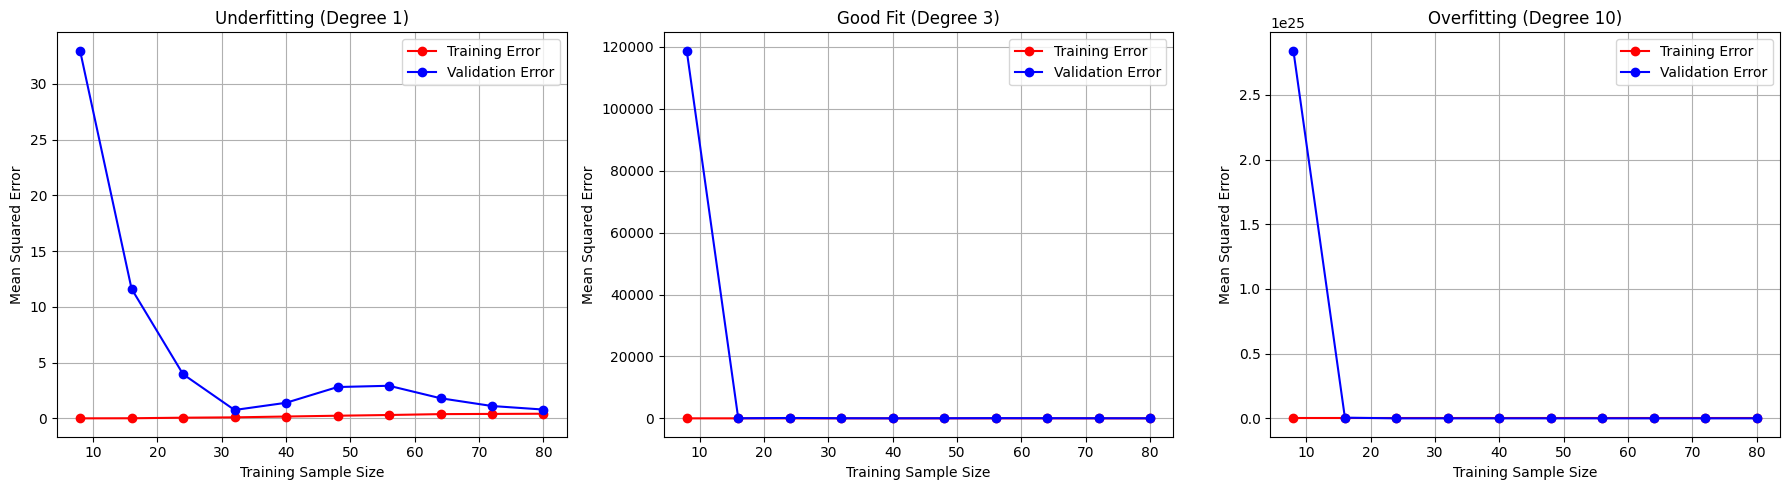

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

# 生成非线性数据
np.random.seed(42)
x = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(x) + 0.1 * np.random.randn(100).reshape(-1, 1)  # 正弦曲线 + 噪声

# 定义不同复杂度的模型
models = {
    "Underfitting (Degree 1)": Pipeline([
        ('poly', PolynomialFeatures(degree=1)),
        ('linear', LinearRegression())
    ]),
    "Good Fit (Degree 3)": Pipeline([
        ('poly', PolynomialFeatures(degree=3)),
        ('linear', LinearRegression())
    ]),
    "Overfitting (Degree 10)": Pipeline([
        ('poly', PolynomialFeatures(degree=10)),
        ('linear', LinearRegression())
    ])
}

# 绘制学习曲线
plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=x,
        y=y,
        cv=5,
        scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    
    # 转换为MSE
    train_scores = -np.mean(train_scores, axis=1)
    test_scores = -np.mean(test_scores, axis=1)
    
    plt.subplot(1, 3, i+1)
    plt.plot(train_sizes, train_scores, 'o-', color='r', label='Training Error')
    plt.plot(train_sizes, test_scores, 'o-', color='b', label='Validation Error')
    plt.xlabel('Training Sample Size')
    plt.ylabel('Mean Squared Error')
    plt.title(name)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()